In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Service Logic (M/M/s Core Formulas)

In [2]:
def calculateP0(lambd, mu, s):
    sumTerm = sum([(lambd / mu) ** n / math.factorial(n) for n in range(s)])
    lastTerm = ((lambd / mu) ** s) / (math.factorial(s) * (1 - (lambd / (s * mu))))
    return 1 / (sumTerm + lastTerm)

def calculateLq(lambd, mu, s, p0, rho):
    numerator = p0 * ((lambd / mu) ** s) * rho
    denominator = math.factorial(s) * ((1 - rho) ** 2)
    return numerator / denominator

def calculateQueueMetrics(row, sOverride=None):
    lambd = row['lambda_arrival']
    mu = row['mu_service']
    s = sOverride if sOverride is not None else row['cs_count']
    
    rho = lambd / (s * mu)
    if rho >= 1:
        return pd.Series([rho, 1.0, np.inf, np.inf, np.inf, np.inf])
        
    p0 = calculateP0(lambd, mu, s)
    lq = calculateLq(lambd, mu, s, p0, rho)
    ls = lq + (lambd / mu)
    wq = (lq / lambd) * 60 
    ws = (ls / lambd) * 60 
    
    return pd.Series([rho, p0, lq, ls, wq, ws])

# Data Loading & Scenario Execution

In [4]:
dfAntrean = pd.read_csv('data_antrean.csv')

metricsCols = ['rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']

dfRiyals = dfAntrean.copy()
dfRiyals[metricsCols] = dfRiyals.apply(calculateQueueMetrics, axis=1)

dfSkenarioBaru = dfAntrean.copy()
dfSkenarioBaru[metricsCols] = dfSkenarioBaru.apply(lambda row: calculateQueueMetrics(row, sOverride=2), axis=1)

print("--- KONDISI 1 CS ---")
print(dfRiyals[['blok_jam', 'rho', 'wq_minutes', 'lq']])
print("\n--- SKENARIO 2 CS ---")
print(dfSkenarioBaru[['blok_jam', 'rho', 'wq_minutes', 'lq']])

--- KONDISI 1 CS ---
  blok_jam       rho  wq_minutes        lq
0        A  0.428571    6.428571  0.321429
1        B  0.625000   12.500000  1.041667
2        C  0.625000   12.500000  1.041667
3        D  0.375000    4.500000  0.225000
4        E  0.333333    5.000000  0.166667
5        F  0.285714    3.428571  0.114286

--- SKENARIO 2 CS ---
  blok_jam       rho  wq_minutes        lq
0        A  0.214286    0.412529  0.020626
1        B  0.312500    0.811688  0.067641
2        C  0.312500    0.811688  0.067641
3        D  0.187500    0.273279  0.013664
4        E  0.166667    0.285714  0.009524
5        F  0.142857    0.178571  0.005952


# Visualisasi

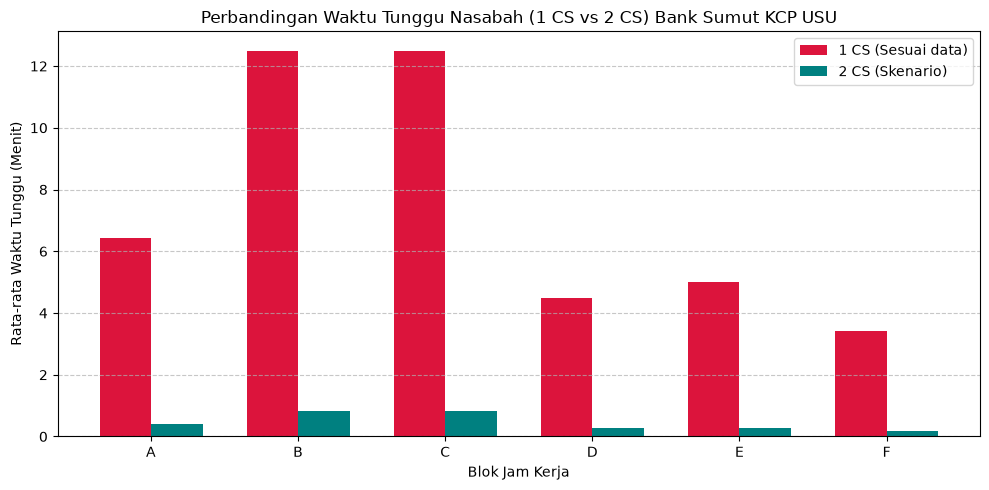

In [6]:
plt.figure(figsize=(10, 5))
x = np.arange(len(dfAntrean['blok_jam']))
width = 0.35

plt.bar(x - width/2, dfRiyals['wq_minutes'], width, label='1 CS (Sesuai data)', color='crimson')
plt.bar(x + width/2, dfSkenarioBaru['wq_minutes'], width, label='2 CS (Skenario)', color='teal')

plt.xlabel('Blok Jam Kerja')
plt.ylabel('Rata-rata Waktu Tunggu (Menit)')
plt.title('Perbandingan Waktu Tunggu Nasabah (1 CS vs 2 CS) Bank Sumut KCP USU')
plt.xticks(x, dfAntrean['blok_jam'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()